# Epic of Sun - Desafio 1
Training the DeepLabV3 model.
***

This jupyter notebook trains a DeepLabV3 for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the datasets in training and validation
* Build the model
* Train the model
* Evaluate the training

***

## Loading libraries and data

In [4]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import random
import math

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
#import joblib
from pathlib import Path
#import os

import tensorflow as tf
#from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from keras import layers
from keras.models import Model
#from keras.models import load_model

#import keras_tuner as kt

In [5]:
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


In [6]:
# Flags
flag_load_hyperparams = False
include_swir = False  # Set to True if you want to include SWIR bands

In [7]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [8]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [9]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              8434  
1  data/processed/scene01/masks/patch_0001.npy             12836  
2  data/processed/scene01/masks/patch_0002.npy              9355  
3  data/processed/scene01/masks/patch_0003.npy              3983  
4  data/processed/scene01/masks/patch_0004.npy               805  
44890


## Selecting datasets in training and validation

In [10]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / "deeplabv3" / "deeplabv3_best_hyperparams.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.00005
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 5e-05}


In [11]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [12]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto, include_swir=include_swir):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)

    # Set the shape of the tensors based on whether SWIR bands are included
    if include_swir:
        x.set_shape((128, 128, 6))  # 6 bands
    else:
        x.set_shape((128, 128, 4))  # 4 bands
    y.set_shape((128, 128, 1))

    """
     If the SWIR bands are include but you only want to use the first 4 bands 
     (Blue, Green, Red, NIR), you can slice the tensor as follows:
    # 1. Always set the shape to 6 because that is how it was saved in the TFRecord
    x.set_shape((128, 128, 6))  
    y.set_shape((128, 128, 1))
    # 2. Slice the tensor if you only want to use the first 4 bands (Blue, Green, Red, NIR)
    if not include_swir:
        x = x[..., :4]  # Keeps only channels 0, 1, 2, and 3"""

    scene = parsed["scene"]
    return x, y, scene

def _augment(x, y, scene):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y, scene

def _add_indices(x, y, scene, include_swir=include_swir):
    if include_swir:
        blue, green, red, nir, swir1, swir2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4], x[..., 5]
    else:
        blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    if include_swir:
        x = tf.stack([blue, green, red, nir, swir1, swir2, ndvi, ndwi, evi], axis=-1)
    else:
        x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)

    return x, y, scene

def _drop_scene(x, y, scene):
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True,
                           augment=True, compute_indices=True, keep_scene=False, include_swir=include_swir):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=2,       # fewer simultaneously-open files = less seeking
        block_length=16,      # read 16 records sequentially from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Use this one line instead of the next one to avoid the error "ValueError: 
    # num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(lambda x: _parse_example(x, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)
    # Use this line to avoid overheading the CPU with too many parallel calls, 
    # which can lead to the error "ValueError: num_parallel_calls must be a 
    # tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(lambda x, y, scene: _add_indices(x, y, scene, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)

    # Drop the scene string BEFORE batching, not after -- keeps the batched
    # element structure as plain (x, y), which is what model.fit() expects.
    # Do this before .batch() rather than after, since batching a dropped
    # scalar string alongside numeric tensors is exactly what caused the
    # XLA_GPU_JIT error you hit.
    if not keep_scene:
        ds = ds.map(_drop_scene, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [13]:
# Create TensorFlow datasets for training, validation, and testing
# Only train and validation is going to be used in this notebook, so no test dataset is created.
train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True, include_swir=include_swir)
val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True, include_swir=include_swir)
#test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False, include_swir=include_swir)

I0000 00:00:1788163644.622731    6289 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [14]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
print("Training batches:", n_train)
print("Validation batches:", n_val)
#print("Testing batches:", n_test)

Training batches: 26934
Validation batches: 8978


In [15]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(train_ds))

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

2026-08-31 05:07:34.652424: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-08-31 05:07:44.652471: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 570 of 2000
2026-08-31 05:07:54.714214: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1527 of 2000
2026-08-31 05:08:02.344630: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: <dtype: 'float32'>
Training label data type: <dtype: 'float32'>


## Build the Model

In [16]:
# Loss functions

# Binary cross-entropy treats every pixel independently and doesn't "know" about overlap; 
# Dice loss directly optimizes for segmentation overlap, which is exactly what IoU measures, 
# and it tends to push recall up for the minority-in-that-image foreground class without 
# hurting precision much.

@tf.keras.utils.register_keras_serializable()
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

@tf.keras.utils.register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable()
def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [17]:
# =============================================================================
# 1. Dilated ResNet34 backbone
#    Same idea as your DSCA-PSPNet backbone, but WITHOUT the D-scSE attention
#    blocks — DeepLabV3 doesn't use them, and keeping this backbone "plain"
#    matters for a fair controlled comparison (architecture should be the only
#    variable that changes between your experiments).
# =============================================================================

def basic_residual_block(x, filters, stride=1, dilation=1, name=""):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding="same",
                       dilation_rate=dilation, use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                       dilation_rate=dilation, use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same",
                                  use_bias=False, name=f"{name}_shortcut_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_shortcut_bn")(shortcut)

    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    return x

In [18]:
# Function to create a ResNet layer with multiple residual blocks
def resnet_layer(x, filters, n_blocks, stride=1, dilation=1, name=""):
    x = basic_residual_block(x, filters, stride=stride, dilation=dilation, name=f"{name}_block1")
    for i in range(2, n_blocks + 1):
        x = basic_residual_block(x, filters, stride=1, dilation=dilation, name=f"{name}_block{i}")
    return x

In [19]:
# Function to create a dilated ResNet34 backbone for DeepLabV3
def dilated_resnet34_backbone(inputs):
    """
    Output stride 8: stem (/2) -> maxpool (/2) -> layer2 (/2) = /8 total.
    layer3 and layer4 use dilation instead of further striding, so resolution
    is frozen at 1/8 of input size from layer2 onward — this feature map is
    what ASPP operates on.
    """
    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation("relu", name="stem_relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same", name="stem_pool")(x)

    x = resnet_layer(x, 64, n_blocks=3, stride=1, dilation=1, name="layer1")     # low-level features (unused in plain V3)
    x = resnet_layer(x, 128, n_blocks=4, stride=2, dilation=1, name="layer2")    # /8 resolution reached here
    x = resnet_layer(x, 256, n_blocks=6, stride=1, dilation=2, name="layer3")    # dilated, stays at /8
    x = resnet_layer(x, 512, n_blocks=3, stride=1, dilation=4, name="layer4")    # dilated, stays at /8

    return x

In [20]:
# =============================================================================
# 2. ASPP module — the defining piece of DeepLabV3
#
#    5 parallel branches, all computed on the SAME feature map at the SAME
#    resolution:
#      - one 1x1 conv (captures local/pointwise features, rate has no effect here)
#      - three 3x3 atrous convs at increasing dilation rates
#      - one global-average-pool branch for whole-image context
#    All 5 are concatenated, then projected back down with a 1x1 conv.
#
#    Rates (12, 24, 36) are the paper's recommended values specifically for
#    output stride 8 (they use (6,12,18) for output stride 16 — since our
#    backbone above uses OS=8, matching your 128x128 patches, these are the
#    correct rates to use, not an arbitrary choice).
# =============================================================================

def aspp_module(x, filters=256, rates=(12, 24, 36)):
    input_size = x.shape[1:3]
    branches = []

    # Branch 1: plain 1x1 conv
    b0 = layers.Conv2D(filters, 1, padding="same", use_bias=False, name="aspp_b0_conv")(x)
    b0 = layers.BatchNormalization(name="aspp_b0_bn")(b0)
    b0 = layers.Activation("relu", name="aspp_b0_relu")(b0)
    branches.append(b0)

    # Branches 2-4: atrous 3x3 convs at each rate
    for rate in rates:
        b = layers.Conv2D(filters, 3, padding="same", dilation_rate=rate,
                           use_bias=False, name=f"aspp_rate{rate}_conv")(x)
        b = layers.BatchNormalization(name=f"aspp_rate{rate}_bn")(b)
        b = layers.Activation("relu", name=f"aspp_rate{rate}_relu")(b)
        branches.append(b)

    # Branch 5: image-level (global) pooling for whole-scene context
    gp = layers.GlobalAveragePooling2D(keepdims=True, name="aspp_gp_pool")(x)  # (B, 1, 1, C)
    gp = layers.Conv2D(filters, 1, padding="same", use_bias=False, name="aspp_gp_conv")(gp)
    gp = layers.BatchNormalization(name="aspp_gp_bn")(gp)
    gp = layers.Activation("relu", name="aspp_gp_relu")(gp)
    gp = layers.Resizing(input_size[0], input_size[1], interpolation="bilinear",
                          name="aspp_gp_upsample")(gp)
    branches.append(gp)

    # Concatenate all 5 branches, then project back down (avoids channel explosion)
    x = layers.Concatenate(name="aspp_concat")(branches)
    x = layers.Conv2D(filters, 1, padding="same", use_bias=False, name="aspp_project_conv")(x)
    x = layers.BatchNormalization(name="aspp_project_bn")(x)
    x = layers.Activation("relu", name="aspp_project_relu")(x)
    x = layers.Dropout(0.1, name="aspp_project_dropout")(x)  # standard practice per the paper
    return x

In [21]:
# =============================================================================
# 3. Full DeepLabV3 model
# =============================================================================
def build_deeplabv3(input_shape=(128, 128, 7), lr=1e-3, aspp_filters=256):
    inputs = layers.Input(input_shape)

    backbone_out = dilated_resnet34_backbone(inputs)      # 1/8 resolution
    x = aspp_module(backbone_out, filters=aspp_filters)   # still 1/8 resolution

    # Plain DeepLabV3: no decoder, just a classifier head + direct bilinear upsample
    x = layers.Conv2D(1, 1, name="classifier_logits")(x)
    x = layers.Resizing(input_shape[0], input_shape[1], interpolation="bilinear",
                         name="final_upsample")(x)
    outputs = layers.Activation("sigmoid", name="output_sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=combined_loss(alpha=0.7),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
        ]
    )
    return model

In [22]:
# Create the model with the best hyperparameters and the right input shape based on whether SWIR bands are included or not
if include_swir:
    input_shape = (128, 128, 9)
else:
    input_shape = (128, 128, 7)

model = build_deeplabv3(
    input_shape=input_shape,
    lr=saved_params["lr"],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │     21,952 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_bn1   │ (None, 32, 32,    │        256 │ layer1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_relu1 │ (None, 32, 32,    │          0 │ layer1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_conv2 │ (None, 32, 32,    │     36,864 │ layer1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_bn2   │ (None, 32, 32,    │        256 │ layer1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_add   │ (None, 32, 32,    │          0 │ layer1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_relu2 │ (None, 32, 32,    │          0 │ layer1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_conv1 │ (None, 32, 32,    │     36,864 │ layer1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_bn1   │ (None, 32, 32,    │        256 │ layer1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_relu1 │ (None, 32, 32,    │          0 │ layer1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_conv2 │ (None, 32, 32,    │     36,864 │ layer1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_bn2   │ (None, 32, 32,    │        256 │ layer1_block2_co

 Total params: 25,449,409 (97.08 MB)

 Trainable params: 25,429,313 (97.01 MB)

 Non-trainable params: 20,096 (78.50 KB)

## Train the model

In [23]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "deeplabv3" / "deeplabv3_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [24]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [25]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

In [26]:
# Train the model
print("Training a new model.")
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=100,
	callbacks=[checkpoint, early_stop, reduce_lr],
	verbose=1
)
history_dict = history.history
print("Training completed.")

Training a new model.
Epoch 1/100


2026-08-31 05:08:34.501333: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 692 of 2000
2026-08-31 05:08:50.169914: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
I0000 00:00:1788163730.925080    7045 service.cc:148] XLA service 0x7586ec015320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788163731.272345    7045 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-31 05:08:55.530420: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788163738.219877    7045 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-08-31 05:09:16.096771: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.02Gi

420/421 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - binary_accuracy: 0.7057 - loss: 0.5288 - precision: 0.6342 - recall: 0.6278

2026-08-31 05:15:06.719583: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 15.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-08-31 05:15:09.253640: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=1,k3=0} for conv (f32[256,69984,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[512,69984,3,3]{3,2,1,0}, f32[512,256,3,3]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2026-08-31 05:15:09.624905: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation

421/421 ━━━━━━━━━━━━━━━━━━━━ 565s 1s/step - binary_accuracy: 0.7549 - loss: 0.4713 - precision: 0.6933 - recall: 0.7014 - val_binary_accuracy: 0.6708 - val_loss: 0.5986 - val_precision: 0.6999 - val_recall: 0.4497 - learning_rate: 5.0000e-05
Epoch 2/100


...


Epoch 44: ReduceLROnPlateau reducing learning rate to 1.9531249506599124e-07.
421/421 ━━━━━━━━━━━━━━━━━━━━ 330s 784ms/step - binary_accuracy: 0.8919 - loss: 0.2484 - precision: 0.8692 - recall: 0.8612 - val_binary_accuracy: 0.8738 - val_loss: 0.2755 - val_precision: 0.8604 - val_recall: 0.8537 - learning_rate: 3.9062e-07
Epoch 45/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - binary_accuracy: 0.8914 - loss: 0.2506 - precision: 0.8674 - recall: 0.8610

2026-08-31 09:10:39.225155: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554432 bytes after encountering the first element of size 33554432 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


421/421 ━━━━━━━━━━━━━━━━━━━━ 280s 660ms/step - binary_accuracy: 0.8921 - loss: 0.2486 - precision: 0.8697 - recall: 0.8610 - val_binary_accuracy: 0.8750 - val_loss: 0.2736 - val_precision: 0.8555 - val_recall: 0.8638 - learning_rate: 1.9531e-07
Epoch 46/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - binary_accuracy: 0.8919 - loss: 0.2491 - precision: 0.8676 - recall: 0.8620

2026-08-31 09:15:28.444527: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554432 bytes after encountering the first element of size 33554432 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


421/421 ━━━━━━━━━━━━━━━━━━━━ 304s 716ms/step - binary_accuracy: 0.8928 - loss: 0.2479 - precision: 0.8712 - recall: 0.8611 - val_binary_accuracy: 0.8205 - val_loss: 0.3894 - val_precision: 0.8944 - val_recall: 0.6746 - learning_rate: 1.9531e-07
Epoch 47/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 326s 757ms/step - binary_accuracy: 0.8925 - loss: 0.2483 - precision: 0.8701 - recall: 0.8618 - val_binary_accuracy: 0.8750 - val_loss: 0.2742 - val_precision: 0.8600 - val_recall: 0.8574 - learning_rate: 1.9531e-07
Training completed.


In [27]:
# Save the model and its history for future use.

# Save the model in the Keras format (.keras) which includes both architecture and weights.
model_path = base_path / "models" / "deeplabv3" / "deeplabv3_sugarcane.keras"
model.save(str(model_path))
print(f"Model saved to '{model_path}'")

# Save the training history as a JSON file for future reference.
history_path = base_path / "models" / "deeplabv3" / "deeplabv3_training_history.json"
with open(str(history_path), 'w') as f:
	json.dump(history_dict, f)
print(f"Training history saved to '{history_path}'")


Model saved to '/home/fdesmello/Git/spacesugar2/models/deeplabv3/deeplabv3_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar2/models/deeplabv3/deeplabv3_training_history.json'


## Evaluate the training


Visualization saved as '/home/fdesmello/Git/spacesugar2/figures/deeplabv3/deeplabv3_loss_accuracy.png'


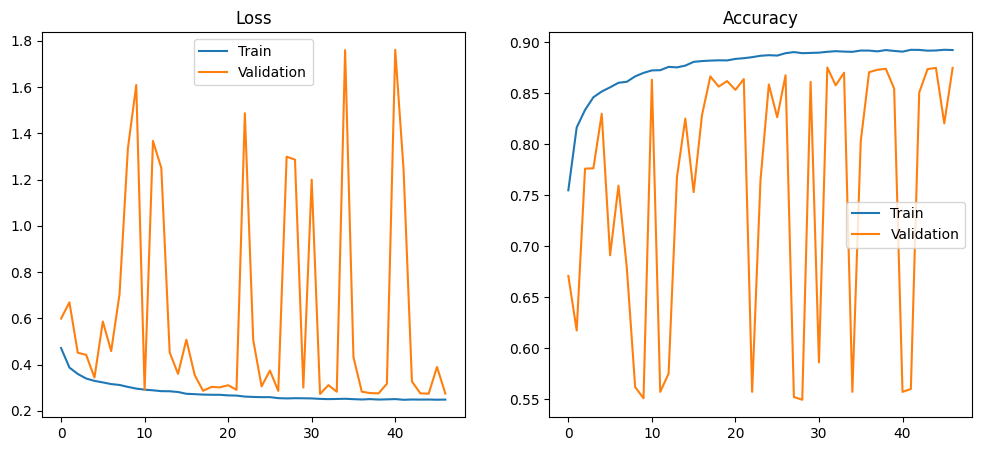

In [28]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "deeplabv3" / "deeplabv3_loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()